In [84]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [89]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

# unique_genres = set("|".join(movies["genres"]).split("|"))
# unique_genres = list(unique_genres)
unique_genres = ['Action', 'Thriller', 'Romance', 'Western', "Children's", 'Mystery', 'Fantasy', 'Film-Noir', 'Documentary', 'Comedy', 'Adventure', 'Sci-Fi', 'Horror', 'Crime', 'Musical', 'War', 'Animation', 'Drama']
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()                                                                               
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
# item_feature_modality = FeatureModality(
#     features=item_features_numpy, ids=ids, normalized=True
# )


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)
# user_feature_modality = FeatureModality(
#     features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
# )

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)
(3416, 18)


In [91]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data
unique_genres.__len__()

18

In [93]:
user_ids = users.to_numpy()[:, 0]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()

6040

In [5]:
reco_matrix=np.load('reco_matrix.npy' )
reco_matrix_mapped_items=np.load('reco_matrix_mapped_items.npy' )
reco_matrix_mapped_scores=np.load('reco_matrix_mapped_scores.npy' )
reco_matrix_all=np.load('reco_matrix_all.npy' )
reco_matrix_all_edited=np.load('reco_items_scores_all.npy' )

#reco_matrix_all_items

In [54]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']


In [116]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []
        
        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]
        
        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []
 

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution


    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))
        
        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)
       
        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)
      
        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )
       

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0
        

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0,50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [112]:
score_dicts = []
for i in range(reco_matrix_all[1].shape[0]):
    iids = reco_matrix_all[1][i]
    score = reco_matrix_all_edited[i]
    score_dicts.append(OrderedDict(zip(iids,score)))

In [117]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file":"./cornac/data_c/user_genre_dist.csv"}
c=Calibration(config=config, movies=movies,top_k=20, unique_genres=unique_genres, users=users)
#for itemknn

reranked_reco=c.get_improved_reco(reco_matrix_n,reco_matrix_all[1],score_dicts)

['Action', 'Thriller', 'Romance', 'Western', "Children's", 'Mystery', 'Fantasy', 'Film-Noir', 'Documentary', 'Comedy', 'Adventure', 'Sci-Fi', 'Horror', 'Crime', 'Musical', 'War', 'Animation', 'Drama']
[207]
[207, 1562]
[207, 1562, 2028]
[207, 1562, 2028, 829]
[207, 1562, 2028, 829, 1654]
[207, 1562, 2028, 829, 1654, 682]
[207, 1562, 2028, 829, 1654, 682, 969]
[207, 1562, 2028, 829, 1654, 682, 969, 1783]
[207, 1562, 2028, 829, 1654, 682, 969, 1783, 2008]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)
    
    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if (movies.at[index,genre]==1):
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd,movies, how="inner",on="itemID")
mergde_pd

,userID,itemID,Rating,Timestamp,movieID,genres,Romance,Comedy,Drama,Musical,...,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
0,0,0,5,978300760,1193,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,3,978302109,661,Animation|Children's|Musical,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,0,2,3,978301968,914,Musical|Romance,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,3,4,978300275,3408,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999606,6039,772,1,956716541,1091,Comedy,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
999607,6039,1106,5,956704887,1094,Drama|Romance|War,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
999608,6039,365,5,956704746,562,Comedy|Drama,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
999609,6039,152,4,956715648,1096,Drama,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
user_genre_means = mergde_pd.groupby('userID')[unique_genres].mean()
user_genre_means


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
userID,,,,,,,,,,,,,,,,,,
0,0.113208,0.264151,0.396226,0.264151,0.094340,0.037736,0.056604,0.377358,0.000000,0.339623,0.094340,0.056604,0.000000,0.000000,0.037736,0.000000,0.056604,0.000000
1,0.186047,0.193798,0.612403,0.000000,0.434109,0.116279,0.240310,0.000000,0.000000,0.000000,0.147287,0.131783,0.023256,0.015504,0.093023,0.023256,0.007752,0.007752
2,0.098039,0.588235,0.156863,0.019608,0.450980,0.039216,0.098039,0.058824,0.000000,0.058824,0.490196,0.117647,0.117647,0.058824,0.000000,0.019608,0.039216,0.000000
3,0.095238,0.000000,0.285714,0.000000,0.904762,0.142857,0.190476,0.047619,0.000000,0.000000,0.285714,0.428571,0.095238,0.142857,0.047619,0.000000,0.095238,0.000000
4,0.151515,0.282828,0.525253,0.015152,0.156566,0.030303,0.196970,0.030303,0.030303,0.020202,0.045455,0.075758,0.005051,0.050505,0.106061,0.040404,0.000000,0.015152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,0.137387,0.293919,0.418919,0.034910,0.173423,0.047297,0.165541,0.060811,0.012387,0.038288,0.093468,0.190315,0.015766,0.083333,0.059685,0.038288,0.021396,0.019144
6036,0.108911,0.292079,0.485149,0.019802,0.138614,0.079208,0.336634,0.029703,0.004950,0.004950,0.044554,0.193069,0.019802,0.044554,0.089109,0.064356,0.019802,0.044554
6037,0.300000,0.600000,0.450000,0.000000,0.100000,0.200000,0.000000,0.050000,0.000000,0.150000,0.050000,0.050000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000


In [ ]:
users

In [ ]:
useer= pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
Gender,,,,,,,,,,,,,,,,,,
0,0.122910,0.333905,0.349891,0.033846,0.293061,0.083442,0.205927,0.063334,0.007557,0.042885,0.146342,0.189403,0.022248,0.077736,0.084999,0.04086,0.037210,0.023263
1,0.209183,0.385891,0.405863,0.054968,0.186861,0.066352,0.167682,0.086136,0.008390,0.053312,0.110675,0.113051,0.012789,0.056306,0.068770,0.04206,0.035231,0.020935


In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z= inter_movies[["userID","itemID","Gender"]]
mergz= pd.merge(z,movies, on="itemID",how="left")
mergz
user_genre_gender = mergz.groupby('Gender')[unique_genres].mean()
user_genre_gender


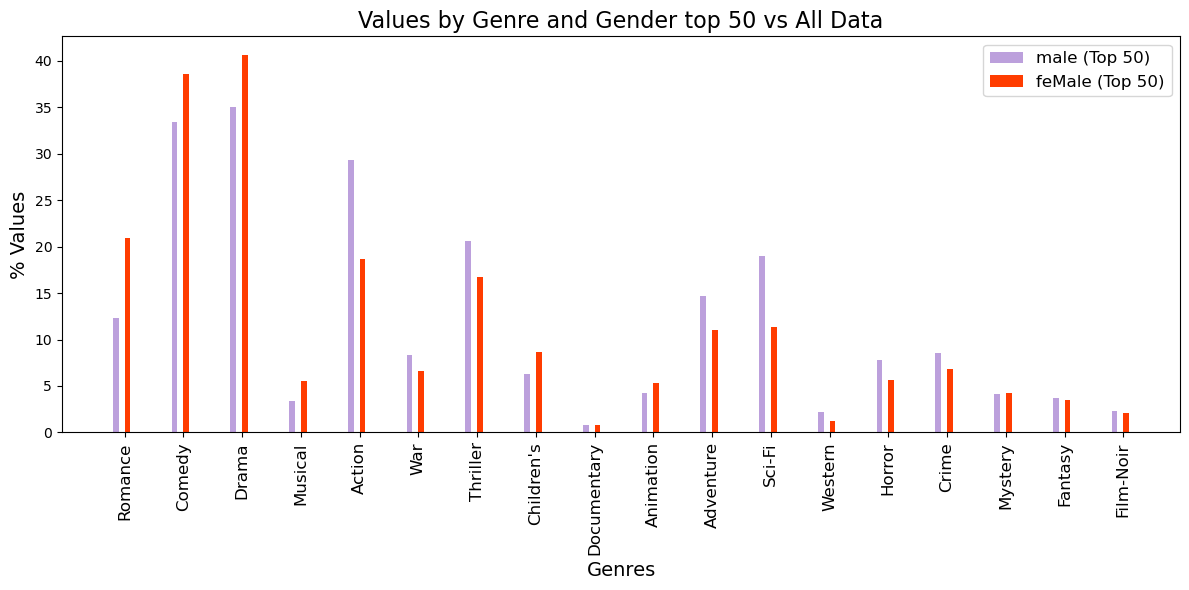

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='feMale (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='female (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

(6040, 50)

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Romance,Comedy,Drama,Musical,Action,War,Thriller,Children's,Documentary,Animation,Adventure,Sci-Fi,Western,Horror,Crime,Mystery,Fantasy,Film-Noir
Gender,,,,,,,,,,,,,,,,,,
0,0.058084,0.245154,0.575216,0.015225,0.126931,0.077345,0.147407,0.018375,0.056421,0.051180,0.065574,0.050187,0.012307,0.024909,0.061575,0.043214,0.008455,0.041081
1,0.058419,0.244543,0.574309,0.015340,0.126358,0.075808,0.147307,0.020035,0.056440,0.053899,0.065539,0.049274,0.012213,0.024344,0.060937,0.042506,0.009028,0.040913


In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame


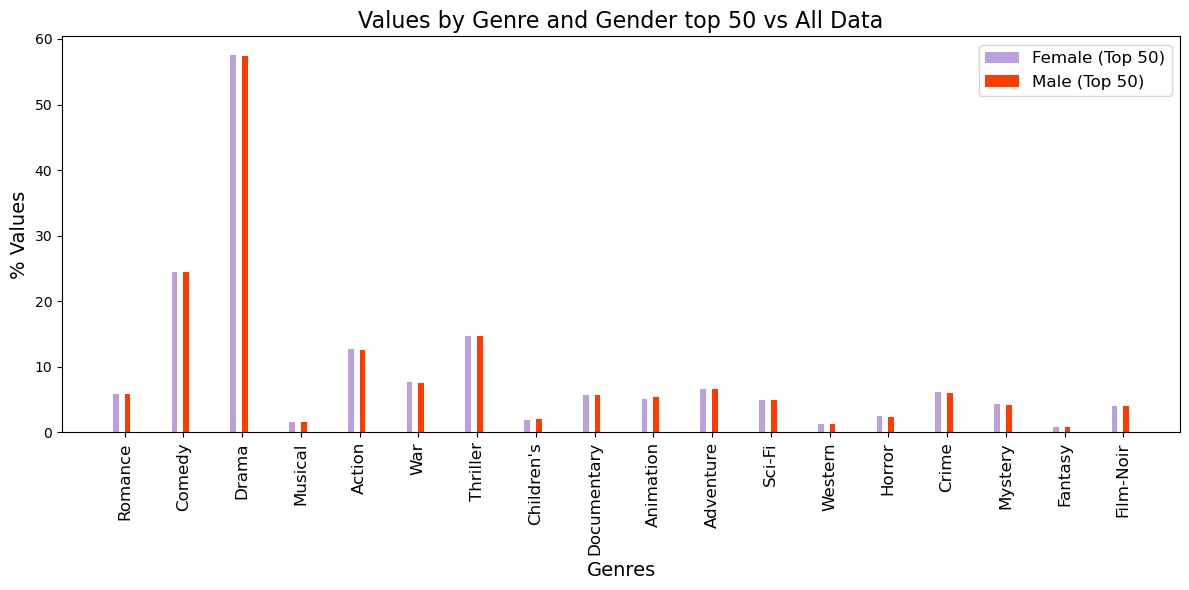

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix.shape[0] + 1).repeat(reco_matrix.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv('biased_movie_lens.csv')

In [ ]:
movies_df

Romance        211.000000
Comedy         737.933333
Drama          961.233333
Musical         52.850000
Action         224.600000
War             64.433333
Thriller       249.100000
Children's     104.316667
Documentary     79.500000
Animation       42.116667
Adventure      110.083333
Sci-Fi         121.283333
Western         42.166667
Horror         234.016667
Crime           90.950000
Mystery         45.950000
Fantasy         22.383333
Film-Noir       22.083333
dtype: float64

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)